# 25. 중간지대 4품목에 출하량을 붙이고 다시 재기

## Overview

21번에서 **출하량이 어느 날을 믿을지 고르는 데 값을 한다**는 걸 확인했습니다:
커버리지를 맞춰 비교하니 30~60% 구간에서 노이즈를 넘었고 40% 에서 **+2.97%p**
였습니다. 하필 운영 지점(32%)이 그 구간입니다.

**그런데 그때 쓴 6품목 중 중간지대는 배추 하나뿐이었습니다.** 상추·얼갈이배추·
풋고추에는 출하량이 아예 없었습니다.

그래서 datago 출하량을 백필했습니다. 이제 **중간지대 4품목이 전부 출하량을
갖췄습니다.** 21번과 같은 질문을 이번엔 진짜 대상에 던집니다.

## 무엇이 달라졌나

| | 21번 | 이 문서 |
|---|---|---|
| 대상 | 출하량 있는 6품목 | **중간지대 4품목** |
| 그중 중간지대 | 배추 1개 | **4개 전부** |
| 출하량 채움률 | 99% | **99.4~100%** |

백필 내역: 상추(10-05) · 얼갈이배추(10-02) · 풋고추(12-05) 를 2021-01-02 ~
2026-08-07 로 받았습니다. 총 1,664,593행이고 관측일이 기존 6품목과 같습니다
(연 311~314일).

## 가설

| 가설 | 내용 | 맞다면 보여야 할 것 |
|---|---|---|
| **H1** | 중간지대에서도 출하량이 날 고르기를 돕는다 | 커버리지 30~60% 에서 노이즈를 넘는 상승 |
| **H2** | 효과가 21번(6품목)보다 크다 | +2.97%p 를 넘음 |
| **H3** | 돈으로도 개선된다 | 창고비 한도가 16.18% 보다 상승 |

**H2 가 왜 말이 될 수 있나**: 중간지대는 저장이 되면서도 가격이 움직이는
구간이라, 출하 물량 정보가 더 직접적으로 작용할 수 있습니다.

**H2 가 틀릴 수 있는 이유**: 21번의 6품목에는 양파·감자처럼 저장성이 큰
품목이 있었고, 그런 품목일수록 출하량이 재고를 통해 가격에 미치는 경로가
뚜렷할 수 있습니다. 엽채류는 그날 나온 물량을 그날 파는 구조라 이미 가격에
다 반영돼 있을지도 모릅니다.

## 목차

1. 준비
2. 커버리지를 맞춰 비교
3. 돈으로 환산
4. 품목별로
5. 정리

## 1. 준비

15·17·21번과 같은 피처·폴드·하이퍼파라미터입니다. **학습은 19품목 전부**
(19번에서 확정), 평가는 중간지대 4품목입니다.

출하량 피처는 21번과 같은 구성을 씁니다: 원시 7개 + 파생 3개.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingClassifier

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
all_items = sorted(df.item.unique())
중간지대 = ["상추", "얼갈이배추", "풋고추", "배추"]

SHIP = ["shipment_qty", "shipment_amt", "shipment_qty_w1ago", "shipment_qty_w2ago",
        "shipment_qty_w3ago", "shipment_qty_w4ago", "shipment_market_cnt"]

print("중간지대 4품목 출하량 채움률")
display(df[df.item.isin(중간지대)].groupby("item")[SHIP]
          .apply(lambda x: (x.notna().mean() * 100).round(1)))
print(f"\n전체 {len(df):,}행 · {len(all_items)}품목")

중간지대 4품목 출하량 채움률


,shipment_qty,shipment_amt,shipment_qty_w1ago,shipment_qty_w2ago,shipment_qty_w3ago,shipment_qty_w4ago,shipment_market_cnt
item,,,,,,,
배추,99.4,99.4,98.0,98.1,98.2,98.1,99.4
상추,100.0,100.0,98.8,98.8,98.8,98.8,100.0
얼갈이배추,100.0,100.0,98.5,98.5,98.5,98.6,100.0
풋고추,100.0,100.0,98.6,98.6,98.7,98.7,100.0



전체 24,078행 · 19품목


In [2]:
H, THR = 7, 0.20
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
PARAMS = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
              max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]
COVS = [0.8, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]

b = df.copy()
b["_logp"] = np.log(b.price_kg_avg)


def g(c):
    return b.groupby("item")[c]


b["y"] = g("_logp").shift(-H) - b._logp
b["오름"] = b.y > 0
b["미래가격"] = g("price_kg_avg").shift(-H)
for lag in (1, 2, 3, 5, 10, 20):
    b[f"ret{lag}"] = b._logp - g("_logp").shift(lag)
for w in (5, 20, 60):
    mp = max(2, w // 3)
    b[f"dev{w}"] = b._logp - g("_logp").transform(
        lambda s: s.rolling(w, min_periods=mp).mean())
    b[f"vol{w}"] = g("_logp").transform(
        lambda s: s.diff().rolling(w, min_periods=mp).std())
doy = b.price_date.dt.dayofyear
b["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
b["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
b["seas_dev"] = b._logp - (b.groupby(["item", "month"])["_logp"]
                           .transform(lambda s: s.shift(1).expanding(min_periods=20).mean()))
b["item_code"] = pd.Categorical(b.item, categories=all_items).codes

# 출하량 파생 (21번과 동일)
b["_logq"] = np.log1p(b.shipment_qty)
b["ship_ret1"] = b._logq - g("_logq").shift(1)
b["ship_dev20"] = b._logq - g("_logq").transform(
    lambda s: s.rolling(20, min_periods=7).mean())
b["ship_price"] = b.shipment_amt / b.shipment_qty.replace(0, np.nan)
SHIP_F = SHIP + ["ship_ret1", "ship_dev20", "ship_price"]

feat = b.dropna(subset=["y", "미래가격"]).reset_index(drop=True)
BASE = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
        + [f"vol{w}" for w in (5, 20, 60)] + CAL
        + ["doy_sin", "doy_cos", "seas_dev", "item_code"])
print(f"학습·평가 대상 {len(feat):,}행 | 기본 {len(BASE)}피처 · +출하량 {len(BASE+SHIP_F)}피처")


def 돌리기(use, 평가품목, noise=None, seed=None):
    d, use = feat, list(use)
    if noise:
        d = feat.copy()
        rng = np.random.default_rng(seed)
        for j in range(noise):
            d[f"noise{j}"] = rng.normal(size=len(d))
            use.append(f"noise{j}")
    cat = [use.index(c) for c in ("item_code", "month", "dayofweek")]
    out = []
    for s, e in FOLDS:
        s, e = pd.Timestamp(s), pd.Timestamp(e)
        tr = d[d.price_date < s - EMBARGO]
        te = d[(d.price_date >= s) & (d.price_date <= e) & (d.item.isin(평가품목))]
        clf = HistGradientBoostingClassifier(
            categorical_features=sorted(cat), early_stopping=False,
            random_state=42, **PARAMS).fit(tr[use], tr.오름)
        t = te[["item", "price_date", "오름", "price_kg_avg", "미래가격"]].copy()
        t["오를확률"] = clf.predict_proba(te[use])[:, 1]
        out.append(t)
    r = pd.concat(out).reset_index(drop=True)
    r["방향맞음"] = (r.오를확률 > 0.5) == r.오름
    r["확신도"] = (r.오를확률 - 0.5).abs()
    return r


def 커버리지컷(r, cov):
    q = r.확신도.quantile(1 - cov)
    s = r[r.확신도 >= q]
    넣음 = (r.오를확률 > 0.5) & (r.확신도 >= q)
    실현 = np.where(넣음, r.미래가격.values, r.price_kg_avg.values)
    더받은돈 = (실현.mean() / r.price_kg_avg.mean() - 1) * 100
    비율 = 넣음.mean()
    기간 = (r.price_date.max() - r.price_date.min()).days / 365.25
    return {
        "적중률 %": s.방향맞음.mean() * 100,
        "더 받은 돈 %": 더받은돈,
        "창고비 한도 %": 더받은돈 / 비율 if 비율 > 0 else np.nan,
        "품목당 연 창고행": 넣음.sum() / 기간 / r.item.nunique(),
    }

학습·평가 대상 23,945행 | 기본 21피처 · +출하량 31피처


## 2. 커버리지를 맞춰 비교

21번과 같은 방법입니다: 임계값이 아니라 **분위수**로 잘라 두 구성이 같은 수의
날을 남기게 합니다. 노이즈 플로어도 같은 커버리지에서 다시 잽니다(교훈 7).

In [3]:
t0 = time.time()
r_base = 돌리기(BASE, 중간지대)
r_ship = 돌리기(BASE + SHIP_F, 중간지대)

noise_rows = []
for seed in (0, 1, 2, 3, 4):
    rn = 돌리기(BASE, 중간지대, noise=4, seed=seed)
    for cov in COVS:
        noise_rows.append({"seed": seed, "커버리지": cov, **커버리지컷(rn, cov)})
nz = pd.DataFrame(noise_rows)
floor = nz.groupby("커버리지")["적중률 %"].agg(lambda s: s.max() - s.min())
floor_h = nz.groupby("커버리지")["창고비 한도 %"].agg(lambda s: s.max() - s.min())

rows = []
for cov in COVS:
    a, s_ = 커버리지컷(r_base, cov), 커버리지컷(r_ship, cov)
    rows.append({
        "커버리지 %": cov * 100,
        "기본 적중률 %": a["적중률 %"],
        "출하량 적중률 %": s_["적중률 %"],
        "차이 %p": s_["적중률 %"] - a["적중률 %"],
        "노이즈 %p": floor[cov],
        "기본 창고비 한도 %": a["창고비 한도 %"],
        "출하량 창고비 한도 %": s_["창고비 한도 %"],
        "한도 차이 %p": s_["창고비 한도 %"] - a["창고비 한도 %"],
        "한도 노이즈 %p": floor_h[cov],
    })
비교 = pd.DataFrame(rows)
비교["적중률 넘김"] = 비교["차이 %p"].abs() > 비교["노이즈 %p"]
비교["한도 넘김"] = 비교["한도 차이 %p"].abs() > 비교["한도 노이즈 %p"]
display(비교.round(2))
print("\n21번(6품목) 은 커버리지 40% 에서 +2.97%p 였습니다.")
print(f"({time.time()-t0:.0f}초)")

,커버리지 %,기본 적중률 %,출하량 적중률 %,차이 %p,노이즈 %p,기본 창고비 한도 %,출하량 창고비 한도 %,한도 차이 %p,한도 노이즈 %p,적중률 넘김,한도 넘김
0,80.0,69.17,69.49,0.32,0.39,9.95,10.26,0.31,0.22,False,True
1,60.0,72.49,73.11,0.62,0.29,11.72,12.36,0.64,0.45,True,True
2,50.0,74.57,75.20,0.63,0.75,13.63,13.45,-0.18,0.67,False,False
3,40.0,77.75,77.96,0.22,0.72,15.91,15.04,-0.87,1.23,False,False
4,30.0,77.99,78.66,0.67,1.05,16.00,15.71,-0.29,1.09,False,False
5,20.0,79.05,79.91,0.86,0.72,17.02,17.57,0.55,1.20,True,False
6,10.0,79.94,83.95,4.01,1.72,18.20,19.94,1.74,0.81,True,True



21번(6품목) 은 커버리지 40% 에서 +2.97%p 였습니다.
(68초)


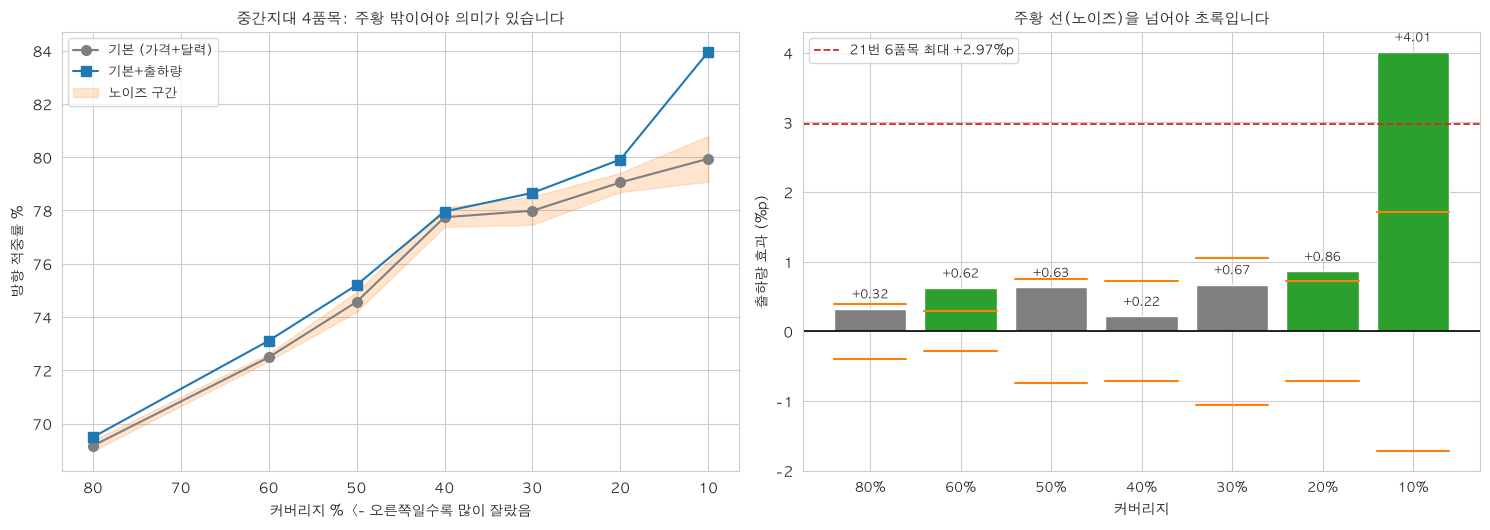

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))
x = 비교["커버리지 %"]

ax = axes[0]
ax.plot(x, 비교["기본 적중률 %"], "o-", ms=7, color="tab:gray", label="기본 (가격+달력)")
ax.plot(x, 비교["출하량 적중률 %"], "s-", ms=7, color="tab:blue", label="기본+출하량")
ax.fill_between(x, 비교["기본 적중률 %"] - 비교["노이즈 %p"] / 2,
                비교["기본 적중률 %"] + 비교["노이즈 %p"] / 2,
                color="tab:orange", alpha=0.2, label="노이즈 구간")
ax.invert_xaxis()
ax.set_xlabel("커버리지 %  <- 오른쪽일수록 많이 잘랐음")
ax.set_ylabel("방향 적중률 %")
ax.set_title("중간지대 4품목: 주황 밖이어야 의미가 있습니다", fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
cols = ["tab:green" if v else "tab:gray" for v in 비교["적중률 넘김"]]
ax.bar(range(len(비교)), 비교["차이 %p"], color=cols)
for i, (v, n) in enumerate(zip(비교["차이 %p"], 비교["노이즈 %p"])):
    ax.plot([i - 0.4, i + 0.4], [n, n], color="tab:orange", lw=1.5)
    ax.plot([i - 0.4, i + 0.4], [-n, -n], color="tab:orange", lw=1.5)
    ax.text(i, v + (0.15 if v >= 0 else -0.3), f"{v:+.2f}", ha="center", fontsize=8.5)
ax.axhline(0, color="black", lw=1.2)
ax.axhline(2.97, color="tab:red", ls="--", lw=1.3, label="21번 6품목 최대 +2.97%p")
ax.set_xticks(range(len(비교)))
ax.set_xticklabels([f"{v:.0f}%" for v in 비교["커버리지 %"]], fontsize=9)
ax.set_xlabel("커버리지")
ax.set_ylabel("출하량 효과 (%p)")
ax.set_title("주황 선(노이즈)을 넘어야 초록입니다", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3. 돈으로 환산

적중률이 올라도 돈이 안 되면 소용없습니다. 17번에서 채택한 **운영 지점
(확신도 0.20 ≈ 커버리지 37%)** 근처에서 창고비 한도를 봅니다.

,커버리지 %,기본 창고비 한도 %,출하량 창고비 한도 %,한도 차이 %p,한도 노이즈 %p,한도 넘김
2,50.0,13.63,13.45,-0.18,0.67,False
3,40.0,15.91,15.04,-0.87,1.23,False
4,30.0,16.00,15.71,-0.29,1.09,False


15번 기준: 중간지대 4품목 확신도 0.20 에서 창고비 한도 16.18% 였습니다.


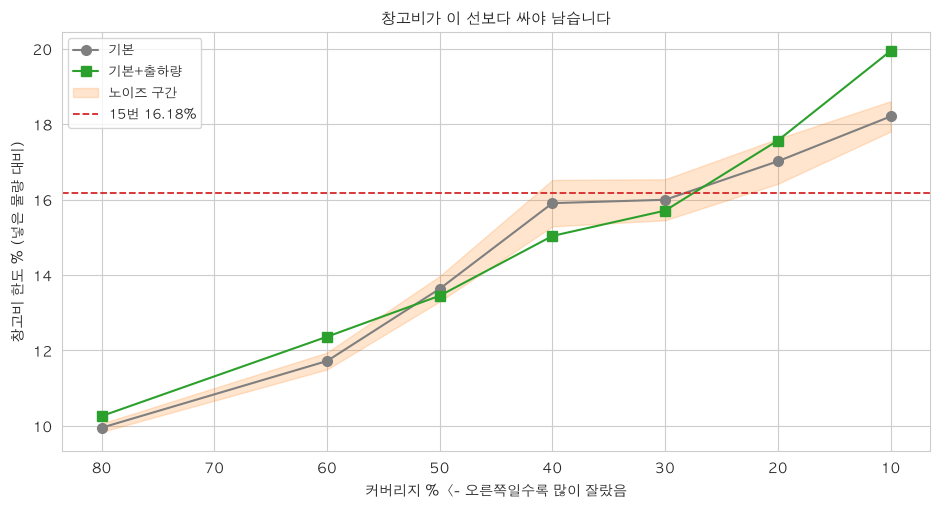

In [5]:
운영 = 비교[비교["커버리지 %"].isin([50.0, 40.0, 30.0])]
display(운영[["커버리지 %", "기본 창고비 한도 %", "출하량 창고비 한도 %",
              "한도 차이 %p", "한도 노이즈 %p", "한도 넘김"]].round(2))
print("15번 기준: 중간지대 4품목 확신도 0.20 에서 창고비 한도 16.18% 였습니다.")

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(x, 비교["기본 창고비 한도 %"], "o-", ms=7, color="tab:gray", label="기본")
ax.plot(x, 비교["출하량 창고비 한도 %"], "s-", ms=7, color="tab:green", label="기본+출하량")
ax.fill_between(x, 비교["기본 창고비 한도 %"] - 비교["한도 노이즈 %p"] / 2,
                비교["기본 창고비 한도 %"] + 비교["한도 노이즈 %p"] / 2,
                color="tab:orange", alpha=0.2, label="노이즈 구간")
ax.axhline(16.18, color="tab:red", ls="--", lw=1.3, label="15번 16.18%")
ax.invert_xaxis()
ax.set_xlabel("커버리지 %  <- 오른쪽일수록 많이 잘랐음")
ax.set_ylabel("창고비 한도 % (넣은 물량 대비)")
ax.set_title("창고비가 이 선보다 싸야 남습니다", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. 품목별로

넷 중 어디서 온 효과인지 봅니다. **배추만 원래 출하량이 있었으니**, 나머지
셋에서 효과가 나야 이번 백필이 값을 한 것입니다.

In [6]:
rows = []
for it in 중간지대:
    a = r_base[r_base.item == it]
    s_ = r_ship[r_ship.item == it]
    q_a = a.확신도.quantile(1 - 0.4)
    q_s = s_.확신도.quantile(1 - 0.4)
    rows.append({
        "item": it,
        "기존 출하량": "있었음" if it == "배추" else "이번에 붙임",
        "기본 적중률 %": a[a.확신도 >= q_a].방향맞음.mean() * 100,
        "출하량 적중률 %": s_[s_.확신도 >= q_s].방향맞음.mean() * 100,
        "관측일": a.price_date.nunique(),
    })
품목별 = pd.DataFrame(rows).set_index("item")
품목별["차이 %p"] = (품목별["출하량 적중률 %"] - 품목별["기본 적중률 %"]).round(2)
display(품목별.round(2))
print("커버리지 40% 기준입니다. 품목별 노이즈는 안 쟀으니 상한으로 읽으세요")
print("(16·17번 경험상 품목 단위는 1.3~2.8%p 로 넓습니다).")

,기존 출하량,기본 적중률 %,출하량 적중률 %,관측일,차이 %p
item,,,,,
상추,이번에 붙임,80.23,80.86,871,0.63
얼갈이배추,이번에 붙임,81.95,82.81,871,0.86
풋고추,이번에 붙임,75.64,75.07,871,-0.57
배추,있었음,70.40,70.69,870,0.29


커버리지 40% 기준입니다. 품목별 노이즈는 안 쟀으니 상한으로 읽으세요
(16·17번 경험상 품목 단위는 1.3~2.8%p 로 넓습니다).


## 5. 정리

### 한 줄 요약

**중간지대에서는 출하량이 거의 값을 안 합니다.** 21번에서 6품목 기준 +2.97%p
였던 효과가 여기서는 운영 지점에서 **+0.22%p** 로 노이즈 이내입니다.
백필은 정상적으로 끝났지만 **기대한 개선은 나오지 않았습니다.**

### 가설 판정

| 가설 | 내용 | 결과 | 판정 |
|---|---|---|---|
| **H1** | 중간지대에서도 날 고르기를 돕는다 | 7개 구간 중 3개만 노이즈 넘김, **운영 지점은 아님** | **부분** |
| **H2** | 효과가 21번(+2.97%p)보다 크다 | 운영 지점 **+0.22%p** | **반증됨** |
| **H3** | 창고비 한도가 16.18% 보다 오른다 | 40% 에서 **-0.87%p** (노이즈 이내) | **반증됨** |

| 커버리지 | 기본 | +출하량 | 차이 | 노이즈 | 넘김 |
|---|---|---|---|---|---|
| 80% | 69.17% | 69.49% | +0.32%p | 0.39 | 아니오 |
| 60% | 72.49% | 73.11% | +0.62%p | 0.29 | **예** |
| 50% | 74.57% | 75.20% | +0.63%p | 0.75 | 아니오 |
| **40%** | 77.75% | 77.96% | **+0.22%p** | 0.72 | 아니오 |
| 30% | 77.99% | 78.66% | +0.67%p | 1.05 | 아니오 |
| 20% | 79.05% | 79.91% | +0.86%p | 0.72 | **예** |
| 10% | 79.94% | 83.95% | **+4.01%p** | 1.72 | **예** |

**운영 지점(30~40%)이 비어 있는 게 결정적입니다.** 17번에서 채택한 확신도
0.20 이 커버리지 37% 근처인데, 하필 거기서 효과가 없습니다.

### 미리 적어둔 두 번째 이유가 맞았습니다

가설 절에 **"H2 가 틀릴 수 있는 이유"** 로 이렇게 적었습니다.

> 21번의 6품목에는 양파·감자처럼 저장성이 큰 품목이 있었고, 그런 품목일수록
> 출하량이 재고를 통해 가격에 미치는 경로가 뚜렷할 수 있습니다. 엽채류는
> 그날 나온 물량을 그날 파는 구조라 이미 가격에 다 반영돼 있을지도 모릅니다.

**중간지대 4품목 중 셋이 엽채류**(상추 10일·얼갈이배추 10일·풋고추 14일)입니다.
저장이 안 되니 출하량이 가격에 즉시 반영되고, 가격 피처(모멘텀·계절 편차)가
그걸 이미 읽고 있는 것으로 보입니다. **관찰이지 증명은 아닙니다.**

이건 14번의 저장성 축과도 이어집니다: 저장이 되는 품목일수록 재고가 완충
역할을 해서 출하량과 가격 사이에 시차가 생기고, 그 시차가 예측할 거리를
만듭니다.

### 품목별로도 작습니다

커버리지 40% 기준입니다.

| 품목 | 기존 출하량 | 기본 | +출하량 | 차이 |
|---|---|---|---|---|
| 얼갈이배추 | 이번에 붙임 | 81.95% | 82.81% | +0.86%p |
| 상추 | 이번에 붙임 | 80.23% | 80.86% | +0.63%p |
| 배추 | 있었음 | 70.40% | 70.69% | +0.29%p |
| **풋고추** | 이번에 붙임 | 75.64% | 75.07% | **-0.57%p** |

**넷 다 품목 단위 노이즈(1.3~2.8%p) 안쪽**이라 개별 판정은 못 합니다.
풋고추가 음수인 것도 노이즈로 읽어야 합니다.

### 커버리지 10% 의 +4.01%p 는 믿지 마세요

가장 큰 값이지만 **남는 날이 4품목 × 871일 × 10% ≈ 350일**뿐입니다. 노이즈
폭도 1.72%p 로 다른 구간의 두 배입니다. 20%·60% 에서 넘긴 것도 각각 +0.86%p ·
+0.62%p 로 **작고 일관되지 않습니다.**

### 그래서 백필은 헛수고였나

**아닙니다. 세 가지가 남습니다.**

- **21번의 결론이 좁혀졌습니다.** "출하량은 날 고르기에 값을 한다"가 아니라
  **"저장성 있는 품목에서 그렇다"** 로 조건이 붙습니다. 21번의 6품목은
  양파·감자·배추·생강이 저장성 쪽이었습니다.
- **데이터는 남습니다.** 상추·얼갈이배추·풋고추의 출하량 5년 반 치가 쌓였고,
  다른 질문에 쓸 수 있습니다.
- **파이프라인이 좋아졌습니다.** `--items` 로 품목을 좁혀 백필할 수 있게 됐고,
  `build_item_dims()` 가 기상 없는 품목도 받습니다. 다음 품목 추가가 쉽습니다.

### 한계

- **엽채류라서인지 중간지대라서인지 못 가릅니다.** 둘이 겹쳐 있어 이 실험만으로는
  분리되지 않습니다. 저장성 긴 품목(양파·감자)만으로 다시 재면 갈릴 것입니다.
- **출하량 피처 구성이 21번과 같습니다.** 엽채류에 맞는 다른 가공(예: 당일
  반입 대비 전주 평균)이 있을 수 있습니다.
- **관측일이 871일**로 다른 노트북(1,372일)보다 적습니다. 폴드 시작이 2023년
  이라 그렇습니다.

### 다음

1. **저장성 축으로 갈라 다시 재기**: 양파·감자·생강(저장 45일 이상)과
   엽채류를 나눠 출하량 효과를 비교하면 위 짐작을 검증할 수 있습니다.
2. **신규 13품목 백필의 우선순위를 다시 내립니다.** 엽채류에서 값을 안 하는
   게 확인됐으니, 남은 품목 중 저장성 있는 것(고구마·무·양배추)부터가 맞습니다.
3. **운영 구성은 그대로 둡니다.** 출하량을 넣어도 운영 지점에서 개선이 없으니,
   15·17번에서 정한 구성을 바꿀 이유가 없습니다.